# Final 2025/26 report

This notebook reports the one-time held-out evaluation. It does not select features, tune models or recalibrate probabilities. It reads the predictions produced by `evaluate_final.py`, compares the pooled player model with the pooled recalibrated market, and measures uncertainty by resampling complete match weeks within each league.

In [7]:
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        expected = candidate / 'scotland_research' / 'config' / 'final_evaluation.json'
        if expected.exists():
            return candidate
    raise FileNotFoundError('Could not find the Super-League-odds-research root.')


PROJECT_ROOT = find_project_root()
RESEARCH_DIR = PROJECT_ROOT / 'scotland_research'
if str(RESEARCH_DIR) not in sys.path:
    sys.path.insert(0, str(RESEARCH_DIR))

from evaluation.report import write_csv_atomic
from uncertainty import (
    METRICS,
    prepare_paired_comparison,
    resample_league_season_weeks,
    summarize_individual_league_intervals,
    summarize_interval,
)

SETTINGS_PATH = RESEARCH_DIR / 'config' / 'final_evaluation.json'
EVALUATION_DIR = PROJECT_ROOT / 'artifacts' / 'final_2025_26_evaluation'
OUTPUT_DIR = RESEARCH_DIR / 'visuals' / 'final_report'
TABLES_DIR = OUTPUT_DIR / 'tables'
FIGURES_DIR = OUTPUT_DIR / 'figures'

print(f'Final evaluation input: {EVALUATION_DIR}')
print(f'Final report outputs: {OUTPUT_DIR}')

Final evaluation input: C:\Users\skous\Super-League-odds-research\artifacts\final_2025_26_evaluation
Final report outputs: C:\Users\skous\Super-League-odds-research\scotland_research\visuals\final_report


## Load and verify the frozen evaluation

The checks below stop the report if the settings changed, if the evaluator outputs are incomplete, or if predictions contain anything other than the five included leagues in 2025/26.

In [8]:
required_files = {
    'predictions': EVALUATION_DIR / 'predictions.csv',
    'equal_league': EVALUATION_DIR / 'equal_league_metrics.csv',
    'match_weighted': EVALUATION_DIR / 'match_weighted_metrics.csv',
    'individual_league': EVALUATION_DIR / 'individual_league_metrics.csv',
    'primary_comparison': EVALUATION_DIR / 'primary_comparison.csv',
    'evaluated_settings': EVALUATION_DIR / 'final_evaluation.json',
    'selected_features': EVALUATION_DIR / 'selected_features.csv',
    'model_settings': EVALUATION_DIR / 'model_settings.json',
    'run_record': EVALUATION_DIR / 'run_record.json',
}
missing = [str(path) for path in required_files.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        'Final evaluation outputs are missing. Run evaluate_final.py first:\n'
        + '\n'.join(missing)
    )

settings = json.loads(SETTINGS_PATH.read_text(encoding='utf-8'))
evaluated_settings = json.loads(
    required_files['evaluated_settings'].read_text(encoding='utf-8')
)
run_record = json.loads(required_files['run_record'].read_text(encoding='utf-8'))
if evaluated_settings != settings:
    raise RuntimeError('The evaluated settings differ from the current fixed settings.')
settings_sha256 = hashlib.sha256(SETTINGS_PATH.read_bytes()).hexdigest()
if run_record.get('settings_file_sha256') != settings_sha256:
    raise RuntimeError('The final evaluation was produced with a different settings file.')
if run_record.get('selected_features_sha256') != settings['selected_features_sha256']:
    raise RuntimeError('The final evaluation used a different selected-feature list.')
if settings.get('post_hoc_calibration') != 'none':
    raise RuntimeError('The final specification must use no post-hoc calibration.')

predictions = pd.read_csv(required_files['predictions'])
equal_league_metrics = pd.read_csv(required_files['equal_league'])
match_weighted_metrics = pd.read_csv(required_files['match_weighted'])
individual_league_metrics = pd.read_csv(required_files['individual_league'])
saved_primary_comparison = pd.read_csv(required_files['primary_comparison'])

observed_seasons = set(predictions['season'].astype(str))
if observed_seasons != {settings['test_season']}:
    raise RuntimeError(
        f"Final predictions have unexpected seasons: {sorted(observed_seasons)}"
    )
observed_leagues = set(predictions['league'].astype(str))
if observed_leagues != set(settings['included_leagues']):
    raise RuntimeError(
        f"Final predictions have unexpected leagues: {sorted(observed_leagues)}"
    )

primary = settings['primary_comparison']
available = set(
    predictions[['training_scope', 'model']].itertuples(index=False, name=None)
)
required_models = {
    (primary['training_scope'], primary['baseline_model']),
    (primary['training_scope'], primary['player_model']),
}
if not required_models.issubset(available):
    raise RuntimeError(f'Primary final predictions are missing: {required_models - available}')

print(f"Loaded {len(predictions):,} prediction rows for {settings['test_season']}.")
print(f"Included leagues: {', '.join(settings['included_leagues'])}")
print('Post-hoc calibration: none')

Loaded 18,608 prediction rows for 2025-26.
Included leagues: belgium, netherlands, portugal, scotland, turkey
Post-hoc calibration: none


## Final point estimates

Lower log loss, Brier score and RPS are better. In the comparison table, a positive improvement means the player model performed better than the recalibrated market.

In [9]:
equal_results = equal_league_metrics.copy()
equal_results.insert(0, 'aggregation', 'equal_league')
weighted_results = match_weighted_metrics.copy()
weighted_results.insert(0, 'aggregation', 'match_weighted')
overall_results = pd.concat([equal_results, weighted_results], ignore_index=True, sort=False)

primary_models = [primary['baseline_model'], primary['player_model']]
primary_overall_results = overall_results[
    overall_results['training_scope'].eq(primary['training_scope'])
    & overall_results['model'].isin(primary_models)
][
    ['aggregation', 'model', 'matches', 'log_loss', 'brier_score', 'rps']
].sort_values(['aggregation', 'model'], kind='stable')

country_results = individual_league_metrics[
    individual_league_metrics['training_scope'].eq(primary['training_scope'])
    & individual_league_metrics['model'].isin(primary_models)
][
    ['league', 'model', 'matches', 'log_loss', 'brier_score', 'rps']
].sort_values(['league', 'model'], kind='stable')

display(primary_overall_results.reset_index(drop=True))
display(saved_primary_comparison.reset_index(drop=True))
display(country_results.reset_index(drop=True))

,aggregation,model,matches,log_loss,brier_score,rps
0,equal_league,market_plus_player_form,1163,0.958045,0.570928,0.188851
1,equal_league,recalibrated_market,1163,0.956680,0.569730,0.188372
2,match_weighted,market_plus_player_form,1163,0.960354,0.572522,0.189709
3,match_weighted,recalibrated_market,1163,0.958879,0.571190,0.189184


,aggregation,training_scope,baseline_model,player_model,metric,baseline_score,player_score,improvement,relative_improvement_pct,league
0,equal_league,pooled,recalibrated_market,market_plus_player_form,log_loss,0.956680,0.958045,-0.001365,-0.142665,NaN
1,equal_league,pooled,recalibrated_market,market_plus_player_form,brier_score,0.569730,0.570928,-0.001198,-0.210189,NaN
2,equal_league,pooled,recalibrated_market,market_plus_player_form,rps,0.188372,0.188851,-0.000479,-0.254137,NaN
3,match_weighted,pooled,recalibrated_market,market_plus_player_form,log_loss,0.958879,0.960354,-0.001475,-0.153835,NaN
4,match_weighted,pooled,recalibrated_market,market_plus_player_form,brier_score,0.571190,0.572522,-0.001331,-0.233074,NaN
5,match_weighted,pooled,recalibrated_market,market_plus_player_form,rps,0.189184,0.189709,-0.000525,-0.277475,NaN
6,individual_league,pooled,recalibrated_market,market_plus_player_form,log_loss,0.992989,0.999232,-0.006243,-0.628699,belgium
7,individual_league,pooled,recalibrated_market,market_plus_player_form,brier_score,0.594733,0.598894,-0.004161,-0.699578,belgium
8,individual_league,pooled,recalibrated_market,market_plus_player_form,rps,0.203508,0.205531,-0.002023,-0.994205,belgium
9,individual_league,pooled,recalibrated_market,market_plus_player_form,log_loss,0.984346,0.983272,0.001074,0.109144,netherlands


,league,model,matches,log_loss,brier_score,rps
0,belgium,market_plus_player_form,267,0.999232,0.598894,0.205531
1,belgium,recalibrated_market,267,0.992989,0.594733,0.203508
2,netherlands,market_plus_player_form,255,0.983272,0.586369,0.196555
3,netherlands,recalibrated_market,255,0.984346,0.586011,0.196679
4,portugal,market_plus_player_form,211,0.903269,0.537444,0.171004
5,portugal,recalibrated_market,211,0.907355,0.538596,0.171332
6,scotland,market_plus_player_form,184,0.963260,0.571648,0.189600
7,scotland,recalibrated_market,184,0.959588,0.570751,0.189097
8,turkey,market_plus_player_form,246,0.941191,0.560286,0.181564
9,turkey,recalibrated_market,246,0.939121,0.558560,0.181244


## Paired match-week uncertainty intervals

Both models are scored on identical matches. Complete match weeks are resampled inside each league, preserving the natural grouping of fixtures. The fixed number of repetitions and random seed are read from the final settings file.

In [10]:
uncertainty_settings = settings['uncertainty']
REPETITIONS = int(uncertainty_settings['repetitions'])
SEED = int(uncertainty_settings['seed'])
comparison = {
    'comparison': 'Pooled players versus recalibrated market',
    'training_scope': primary['training_scope'],
    'baseline_model': primary['baseline_model'],
    'enhanced_model': primary['player_model'],
}

paired = prepare_paired_comparison(
    predictions,
    training_scope=comparison['training_scope'],
    baseline_model=comparison['baseline_model'],
    enhanced_model=comparison['enhanced_model'],
)
samples = resample_league_season_weeks(
    paired,
    repetitions=REPETITIONS,
    seed=SEED,
)
uncertainty_intervals = summarize_interval(
    paired,
    samples,
    comparison,
    repetitions=REPETITIONS,
    seed=SEED,
)
uncertainty_by_league = summarize_individual_league_intervals(
    paired,
    comparison,
    repetitions=REPETITIONS,
    seed=SEED,
)
match_audit = (
    paired.groupby(['league', 'season'], as_index=False)
    .agg(matches=('match_id', 'size'), match_weeks=('match_week', 'nunique'))
)

display(uncertainty_intervals.reset_index(drop=True))
display(uncertainty_by_league.reset_index(drop=True))
display(match_audit.reset_index(drop=True))

,comparison,training_scope,baseline_model,enhanced_model,weighting,metric,matches,leagues,observed_baseline,observed_enhanced,observed_absolute_improvement,observed_relative_improvement_pct,lower_95_absolute,upper_95_absolute,lower_95_relative_pct,upper_95_relative_pct,samples_favouring_enhanced_pct,interval_excludes_zero,repetitions,seed
0,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,equal_league,log_loss,1163,5,0.956680,0.958045,-0.001365,-0.142665,-0.004874,0.002244,-0.511328,0.234298,22.86,False,10000,42
1,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,equal_league,brier_score,1163,5,0.569730,0.570928,-0.001198,-0.210189,-0.003602,0.001231,-0.633314,0.215425,17.07,False,10000,42
2,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,equal_league,rps,1163,5,0.188372,0.188851,-0.000479,-0.254137,-0.001556,0.000612,-0.827957,0.327144,19.68,False,10000,42
3,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,match_weighted,log_loss,1163,5,0.958879,0.960354,-0.001475,-0.153835,-0.005005,0.002124,-0.523887,0.221254,21.04,False,10000,42
4,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,match_weighted,brier_score,1163,5,0.571190,0.572522,-0.001331,-0.233074,-0.003767,0.001133,-0.658679,0.198704,14.63,False,10000,42
5,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,match_weighted,rps,1163,5,0.189184,0.189709,-0.000525,-0.277475,-0.001615,0.000588,-0.856089,0.313784,17.82,False,10000,42


,comparison,training_scope,baseline_model,enhanced_model,weighting,metric,league,matches,leagues,observed_baseline,...,observed_absolute_improvement,observed_relative_improvement_pct,lower_95_absolute,upper_95_absolute,lower_95_relative_pct,upper_95_relative_pct,samples_favouring_enhanced_pct,interval_excludes_zero,repetitions,seed
0,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,match_weighted,log_loss,belgium,267,1,0.992989,...,-0.006243,-0.628699,-0.013936,0.001348,-1.386097,0.137234,5.48,False,10000,42
1,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,match_weighted,brier_score,belgium,267,1,0.594733,...,-0.004161,-0.699578,-0.009533,0.001094,-1.577638,0.187428,6.40,False,10000,42
2,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,match_weighted,rps,belgium,267,1,0.203508,...,-0.002023,-0.994205,-0.004591,0.000476,-2.207179,0.233797,5.97,False,10000,42
3,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,match_weighted,log_loss,netherlands,255,1,0.984346,...,0.001074,0.109144,-0.006707,0.008383,-0.684342,0.844922,60.79,False,10000,43
4,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,match_weighted,brier_score,netherlands,255,1,0.586011,...,-0.000357,-0.060965,-0.005832,0.004819,-1.006736,0.819324,44.71,False,10000,43
5,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,match_weighted,rps,netherlands,255,1,0.196679,...,0.000124,0.063208,-0.002395,0.002460,-1.261701,1.231409,54.83,False,10000,43
6,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,match_weighted,log_loss,portugal,211,1,0.907355,...,0.004085,0.450255,-0.003655,0.012112,-0.406203,1.313826,84.52,False,10000,44
7,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,match_weighted,brier_score,portugal,211,1,0.538596,...,0.001153,0.214059,-0.003869,0.006218,-0.722802,1.141241,66.38,False,10000,44
8,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,match_weighted,rps,portugal,211,1,0.171332,...,0.000328,0.191305,-0.001862,0.002555,-1.087524,1.487418,59.67,False,10000,44
9,Pooled players versus recalibrated market,pooled,recalibrated_market,market_plus_player_form,match_weighted,log_loss,scotland,184,1,0.959588,...,-0.003672,-0.382630,-0.012635,0.005005,-1.310410,0.528059,20.81,False,10000,45


,league,season,matches,match_weeks
0,belgium,2025-26,267,38
1,netherlands,2025-26,255,34
2,portugal,2025-26,211,36
3,scotland,2025-26,184,36
4,turkey,2025-26,246,34


## Final figure w/ conclusion

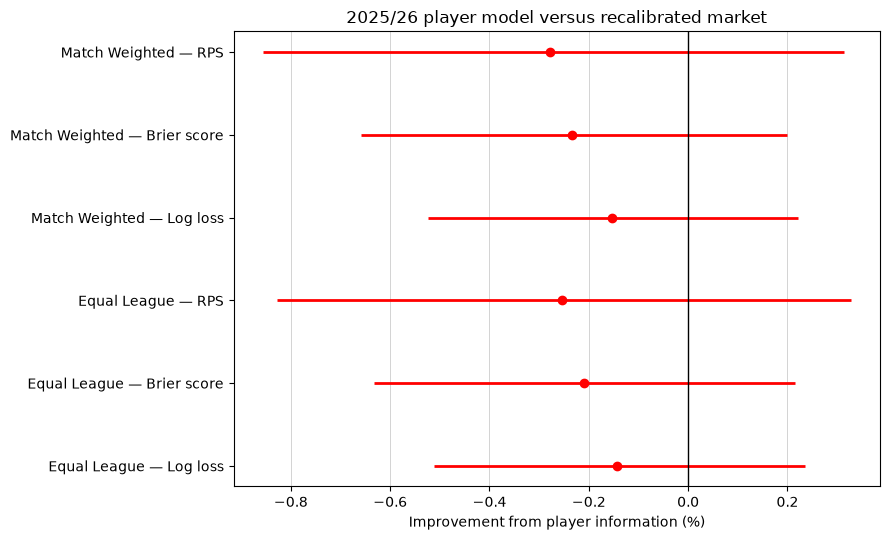

On the primary equal-league log-loss measure, the player model showed a 0.143% deterioration relative to the recalibrated market. The paired 95% interval was -0.511% to 0.234%. The final test does not clearly distinguish the player model from the recalibrated market.
Saved figure: C:\Users\skous\Super-League-odds-research\scotland_research\visuals\final_report\figures\uncertainty_intervals.png


In [11]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plot_data = uncertainty_intervals.copy().reset_index(drop=True)
plot_data['label'] = (
    plot_data['weighting'].str.replace('_', ' ').str.title()
    + ' — '
    + plot_data['metric'].replace(
        {'log_loss': 'Log loss', 'brier_score': 'Brier score', 'rps': 'RPS'}
    )
)

plt.style.use('default')
fig, axis = plt.subplots(figsize=(9, 5.5), facecolor='white')
fig.patch.set_facecolor('white')
axis.set_facecolor('white')
for row_number, row in plot_data.iterrows():
    observed = row['observed_relative_improvement_pct']
    lower = row['lower_95_relative_pct']
    upper = row['upper_95_relative_pct']
    color = 'blue' if observed >= 0 else 'red'
    axis.hlines(row_number, lower, upper, color=color, linewidth=2)
    axis.plot(observed, row_number, 'o', color=color)
axis.axvline(0, color='black', linewidth=1)
axis.set_yticks(range(len(plot_data)), plot_data['label'])
axis.set_xlabel('Improvement from player information (%)')
axis.set_title('2025/26 player model versus recalibrated market')
axis.grid(axis='x', color='lightgray', linewidth=0.7)
fig.tight_layout()
figure_path = FIGURES_DIR / 'uncertainty_intervals.png'
fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches='tight',
    facecolor='white',
    transparent=False,
)
plt.show()

primary_log_loss = uncertainty_intervals[
    uncertainty_intervals['weighting'].eq(settings['aggregation']['primary'])
    & uncertainty_intervals['metric'].eq(settings['metrics']['primary'])
].iloc[0]
observed = primary_log_loss['observed_relative_improvement_pct']
lower = primary_log_loss['lower_95_relative_pct']
upper = primary_log_loss['upper_95_relative_pct']
if lower > 0:
    interpretation = 'The final test supports a clear improvement from recent player information.'
elif upper < 0:
    interpretation = 'The final test supports a clear deterioration from adding recent player information.'
else:
    interpretation = 'The final test does not clearly distinguish the player model from the recalibrated market.'
direction = 'improvement' if observed >= 0 else 'deterioration'
conclusion = (
    f"On the primary equal-league log-loss measure, the player model showed a "
    f"{abs(observed):.3f}% {direction} relative to the recalibrated market. "
    f"The paired 95% interval was {lower:.3f}% to {upper:.3f}%. "
    + interpretation
)
print(conclusion)
print(f'Saved figure: {figure_path}')

## Save the auditable final report outputs

In [12]:
TABLES_DIR.mkdir(parents=True, exist_ok=True)
outputs = {
    'all_model_results': overall_results,
    'primary_model_results': primary_overall_results,
    'primary_comparison': saved_primary_comparison,
    'country_results': country_results,
    'uncertainty_intervals': uncertainty_intervals,
    'uncertainty_by_league': uncertainty_by_league,
    'comparison_match_audit': match_audit,
}
for name, frame in outputs.items():
    write_csv_atomic(frame, TABLES_DIR / f'{name}.csv')

report_settings = {
    'prediction_source': str(required_files['predictions']),
    'test_season': settings['test_season'],
    'included_leagues': settings['included_leagues'],
    'primary_comparison': comparison,
    'post_hoc_calibration': settings['post_hoc_calibration'],
    'uncertainty': uncertainty_settings,
    'settings_file_sha256': settings_sha256,
    'selected_features_sha256': settings['selected_features_sha256'],
}
settings_output = TABLES_DIR / 'report_settings.json'
settings_temporary = settings_output.with_suffix('.json.tmp')
settings_temporary.write_text(
    json.dumps(report_settings, indent=2, sort_keys=True) + '\n',
    encoding='utf-8',
)
settings_temporary.replace(settings_output)

conclusion_output = OUTPUT_DIR / 'conclusion.txt'
conclusion_temporary = conclusion_output.with_suffix('.txt.tmp')
conclusion_temporary.write_text(conclusion + '\n', encoding='utf-8')
conclusion_temporary.replace(conclusion_output)

print(f'Saved final report tables to {TABLES_DIR}')
print(f'Saved conclusion to {conclusion_output}')

Saved final report tables to C:\Users\skous\Super-League-odds-research\scotland_research\visuals\final_report\tables
Saved conclusion to C:\Users\skous\Super-League-odds-research\scotland_research\visuals\final_report\conclusion.txt
